# Test Sokoban Dataset & Evaluation

In [33]:
import os
import sys


sys.path.append(os.path.join("../.."))

In [44]:
import os
from glob import glob

import joblib
import matplotlib.pyplot as plt
import numpy as np
from sokoban_dataset import SokobanBitsDataset, SokobanDatasetTokens
from torch.utils.data import DataLoader

from sokoban.dataset.evaluate_sokoban_boards import generate_metrics


DATA_PATH = "../data/raw/12-12-4"
DATASET_SIZE = 1000
BATCH_SIZE = 64

In [35]:
def render_batch(dataset, batch, key="target", n_show=8):
    """Render first n_show boards from a batch as a grid."""
    boards = batch[key][:n_show]
    fig, axes = plt.subplots(1, n_show, figsize=(2 * n_show, 2))
    for i, board_tensor in enumerate(boards):
        if hasattr(dataset, 'bits_to_tokens'):
            tokens = dataset.bits_to_tokens(board_tensor).numpy()
        else:
            tokens = board_tensor.numpy()
        img = dataset.render_board(tokens)
        axes[i].imshow(img.astype(np.uint8))
        axes[i].axis("off")
    plt.tight_layout()
    plt.show()

## Count dataset

In [49]:
def count_data(data_path: str):
    data_dir_files = sorted(glob(os.path.join(data_path, "*")))
    if not data_dir_files:
        print(f"No files found in {data_path}")
        return

    total_files = len(data_dir_files)
    total_trajectories = 0
    total_boards = 0
    traj_lengths = []

    for f in data_dir_files:
        data: dict = joblib.load(f)
        n_traj = len(data)
        total_trajectories += n_traj
        for traj in data.values():
            traj_np = np.argmax(traj, axis=3).astype(np.uint8)
            traj_len = len(traj_np)
            total_boards += traj_len
            traj_lengths.append(traj_len)

    traj_lengths = np.array(traj_lengths)

    print(f"Data path: {data_path}")
    print(f"{'='*50}")
    print(f"Files:              {total_files}")
    print(f"Trajectories:       {total_trajectories}")
    print(f"Total boards:       {total_boards}")
    print(f"{'='*50}")
    print(f"Avg traj length:    {traj_lengths.mean():.1f}")
    print(f"Min traj length:    {traj_lengths.min()}")
    print(f"Max traj length:    {traj_lengths.max()}")
    print(f"Median traj length: {np.median(traj_lengths):.1f}")
    print()


data_paths = [
    "../data/raw/12-12-4",
    "../data/raw/12-12-4-val",
    "../data/raw/12-12-4-test",
]
for path in data_paths:
    count_data(path)

Data path: ../data/raw/12-12-4
Files:              115
Trajectories:       78000
Total boards:       3846315
Avg traj length:    49.3
Min traj length:    6
Max traj length:    201
Median traj length: 43.0

Data path: ../data/raw/12-12-4-val
Files:              29
Trajectories:       21000
Total boards:       1031018
Avg traj length:    49.1
Min traj length:    6
Max traj length:    201
Median traj length: 43.0

Data path: ../data/raw/12-12-4-test
Files:              16
Trajectories:       13000
Total boards:       636735
Avg traj length:    49.0
Min traj length:    8
Max traj length:    200
Median traj length: 43.0



## 1. Unconditional

Loading Unconditional: 100%|██████████| 1000/1000 [00:00<00:00, 1017.91it/s]


Batch keys: ['target', 'num_boxes']
Target shape: torch.Size([64, 12, 12])


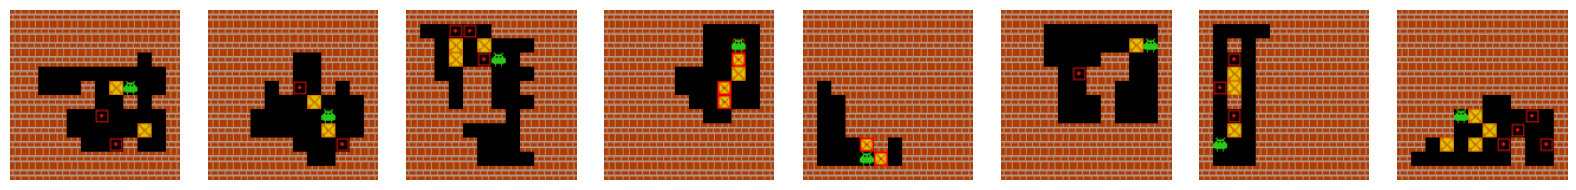

In [40]:
ds_uncond = SokobanDatasetTokens.for_unconditional(DATA_PATH, DATASET_SIZE, bot_removal_prob=0.75)
dl_uncond = DataLoader(ds_uncond, batch_size=BATCH_SIZE, shuffle=True)

batch = next(iter(dl_uncond))
print(f"Batch keys: {list(batch.keys())}")
print(f"Target shape: {batch['target'].shape}")  # (B, 12, 12)

render_batch(ds_uncond, batch)

In [41]:
boards_np = batch["target"].numpy()
metrics_uncond = generate_metrics(boards_np)

print("=== Unconditional Metrics (real data, expect ~100%) ===")
for k, v in sorted(metrics_uncond.items()):
    print(f"  {k}: {v:.2f}")

assert metrics_uncond["sokoban/validity_is_valid_ratio"] == 1.0, f"Expected 100% validity, got {metrics_uncond['sokoban/validity_is_valid_ratio']}"
assert metrics_uncond["sokoban/solvable_in_all_percentage"] == 1.0, f"Expected 100% solvability, got {metrics_uncond['sokoban/solvable_in_all_percentage']}"
print("\nAll boards valid and solvable")

=== Unconditional Metrics (real data, expect ~100%) ===
  sokoban/solvable_in_all_percentage: 1.00
  sokoban/solvable_in_valid_percentage: 1.00
  sokoban/validity_board_connected_ratio: 1.00
  sokoban/validity_boxes_eq_targets_ratio: 1.00
  sokoban/validity_desired_boxes_number_ratio: 1.00
  sokoban/validity_is_valid_ratio: 1.00
  sokoban/validity_one_player_ratio: 1.00

All boards valid and solvable


## 2. Conditional: Num Boxes

Each board is adjusted to have a specific number of boxes (1–4). Evaluation checks that `num_boxes_accuracy` is 100% on real adjusted data.

Building Num Boxes Conditional: 100%|██████████| 1000/1000 [00:00<00:00, 18591.53it/s]


Batch keys: ['target', 'num_boxes']
Target shape: torch.Size([64, 12, 12])
Num boxes labels (first 16): [2, 4, 3, 2, 2, 1, 2, 4, 3, 3, 2, 3, 2, 3, 1, 2]


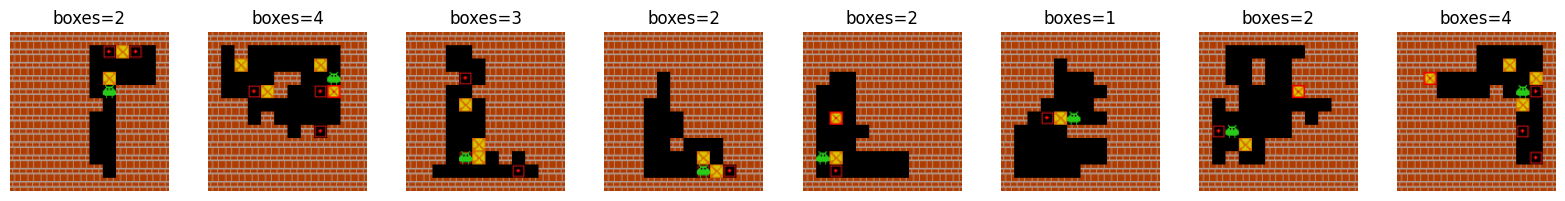

In [27]:
ds_numboxes = SokobanDatasetTokens.for_conditioning_num_boxes_generation(DATA_PATH, DATASET_SIZE)
dl_numboxes = DataLoader(ds_numboxes, batch_size=BATCH_SIZE, shuffle=True)

batch_nb = next(iter(dl_numboxes))
print(f"Batch keys: {list(batch_nb.keys())}")
print(f"Target shape: {batch_nb['target'].shape}")
print(f"Num boxes labels (first 16): {batch_nb['num_boxes'][:16].tolist()}")

n_show = 8
fig, axes = plt.subplots(1, n_show, figsize=(2 * n_show, 2))
for i in range(n_show):
    img = ds_numboxes.render_board(batch_nb["target"][i].numpy())
    axes[i].imshow(img.astype(np.uint8))
    axes[i].set_title(f"boxes={batch_nb['num_boxes'][i].item()}")
    axes[i].axis("off")
plt.tight_layout()
plt.show()

In [28]:
boards_nb = batch_nb["target"].numpy()
num_boxes_labels = batch_nb["num_boxes"].numpy()

metrics_nb = generate_metrics(boards_nb, num_boxes_labels=num_boxes_labels)

print("=== Conditional Num Boxes Metrics (real data, expect 100%) ===")
for k, v in sorted(metrics_nb.items()):
    print(f"  {k}: {v:.2f}")

assert metrics_nb["sokoban/validity_desired_boxes_number_ratio"] == 1.0, f"Expected 100% num_boxes_accuracy, got {metrics_nb['sokoban/validity_desired_boxes_number_ratio']}"
assert metrics_nb["sokoban/solvable_in_all_percentage"] == 1.0, f"Expected 100% solvability, got {metrics_nb['sokoban/solvable_in_all_percentage']}"

print("\nAll metrics returned 100%")

=== Conditional Num Boxes Metrics (real data, expect 100%) ===
  sokoban/solvable_in_all_percentage: 1.00
  sokoban/solvable_in_valid_percentage: 1.00
  sokoban/validity_board_connected_ratio: 1.00
  sokoban/validity_boxes_eq_targets_ratio: 1.00
  sokoban/validity_desired_boxes_number_ratio: 1.00
  sokoban/validity_is_valid_ratio: 1.00
  sokoban/validity_one_player_ratio: 1.00

All metrics returned 100%


## 3. Conditional: K Steps

Each sample has a conditioning board, a target board (k steps away), and the k value.
Evaluation checks `target_in_generated_percentage` = 100% when we pass the real targets as "generated".

Loading K Steps: 1002it [00:00, 2157.84it/s]                     


Batch keys: ['condition', 'target', 'k', 'num_boxes']
Condition shape: torch.Size([64, 12, 12])
Target shape: torch.Size([64, 12, 12])
K values (first 16): [3, 3, 10, 10, 3, 3, 3, 5, 10, 3, 10, 3, 5, 10, 10, 3]
Num boxes (first 16): [3, 2, 4, 2, 3, 4, 4, 4, 4, 1, 3, 4, 2, 3, 4, 4]


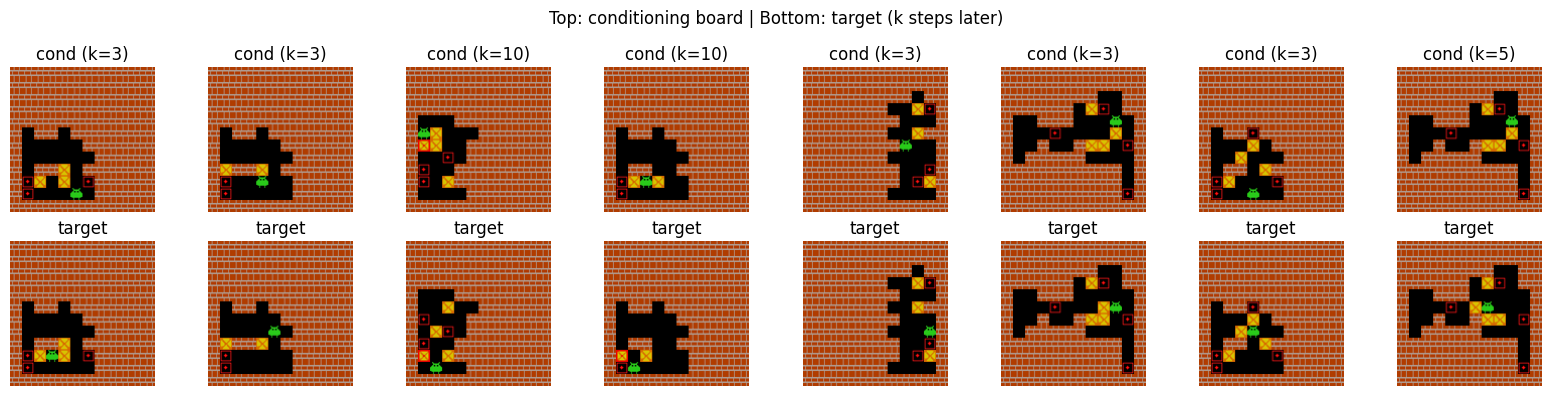

In [29]:
# Conditional k_steps dataset
ds_ksteps = SokobanDatasetTokens.for_conditioning_k_steps_generation(DATA_PATH, DATASET_SIZE, k_values=[3, 5, 10], bot_removal_prob=1.0)
dl_ksteps = DataLoader(ds_ksteps, batch_size=BATCH_SIZE, shuffle=True)

batch_ks = next(iter(dl_ksteps))
print(f"Batch keys: {list(batch_ks.keys())}")
print(f"Condition shape: {batch_ks['condition'].shape}")
print(f"Target shape: {batch_ks['target'].shape}")
print(f"K values (first 16): {batch_ks['k'][:16].tolist()}")
print(f"Num boxes (first 16): {batch_ks['num_boxes'][:16].tolist()}")

# Render condition and target side by side
fig, axes = plt.subplots(2, 8, figsize=(16, 4))
for i in range(8):
    cond_img = ds_ksteps.render_board(batch_ks["condition"][i].numpy())
    tgt_img = ds_ksteps.render_board(batch_ks["target"][i].numpy())
    axes[0, i].imshow(cond_img.astype(np.uint8))
    axes[0, i].set_title(f"cond (k={batch_ks['k'][i].item()})")
    axes[0, i].axis("off")
    axes[1, i].imshow(tgt_img.astype(np.uint8))
    axes[1, i].set_title("target")
    axes[1, i].axis("off")
plt.suptitle("Top: conditioning board | Bottom: target (k steps later)")
plt.tight_layout()
plt.show()

In [30]:
generated_boards = batch_ks["target"].numpy()
conditioning_boards = batch_ks["condition"].numpy()
target_boards = batch_ks["target"].numpy()
k_values = batch_ks["k"].tolist()

metrics_ks = generate_metrics(
    generated_boards=generated_boards,
    conditioning_boards=conditioning_boards,
    target_boards=target_boards,
    k_values=k_values,
    n_images_per_conditioning=1,
)

print("=== Conditional K Steps Metrics (real targets as generated, expect 100%) ===")
for k, v in sorted(metrics_ks.items()):
    print(f"  {k}: {v:.2f}")

assert metrics_ks["sokoban/target_in_generated_percentage"] == 1.0, \
    f"Expected 100% target_in_generated, got {metrics_ks['sokoban/target_in_generated_percentage']}"
assert metrics_ks["sokoban/cond_structure_match_percentage"] == 1.0, \
    f"Expected 100% structure match, got {metrics_ks['sokoban/cond_structure_match_percentage']}"
print("\nAll metrics returned 100%")

=== Conditional K Steps Metrics (real targets as generated, expect 100%) ===
  sokoban/cond_structure_match_percentage: 1.00
  sokoban/in_correct_k_distance_percentage: 1.00
  sokoban/solvable_in_all_percentage: 1.00
  sokoban/solvable_in_valid_percentage: 1.00
  sokoban/target_in_generated_percentage: 1.00
  sokoban/validity_board_connected_ratio: 1.00
  sokoban/validity_boxes_eq_targets_ratio: 1.00
  sokoban/validity_desired_boxes_number_ratio: 1.00
  sokoban/validity_is_valid_ratio: 1.00
  sokoban/validity_one_player_ratio: 1.00

All metrics returned 100%


## 4. Bits Dataset (used by Bit-Diffusion training)

Verify that `SokobanBitsDataset` produces correct `(num_bits, H, W)` tensors in `{-1, +1}` and that round-tripping through `bits_to_tokens` recovers the original board.

Loading Unconditional: 100%|██████████| 1000/1000 [00:00<00:00, 1063.13it/s]

Bits target shape: torch.Size([64, 3, 12, 12])
Value range: [-1.0, 1.0]
Recovered tokens shape: torch.Size([64, 12, 12])
Token value range: [0, 6]


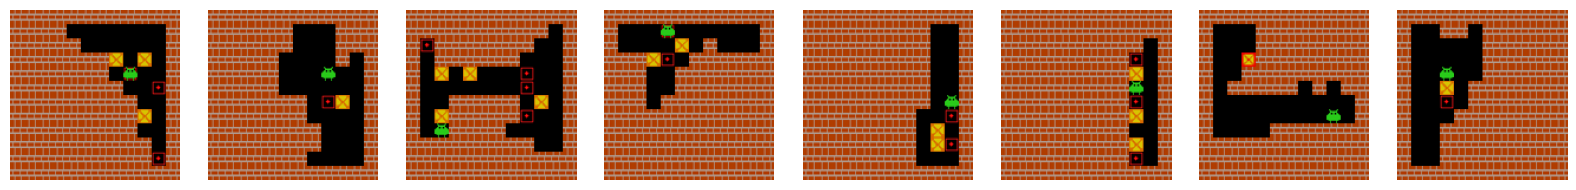


Valid token recovery


In [31]:
ds_bits = SokobanBitsDataset.for_unconditional(DATA_PATH, DATASET_SIZE, bot_removal_prob=1.0)
dl_bits = DataLoader(ds_bits, batch_size=BATCH_SIZE, shuffle=True)

batch_bits = next(iter(dl_bits))
bits_tensor = batch_bits["target"]
print(f"Bits target shape: {bits_tensor.shape}")  # (B, 3, 12, 12)
print(f"Value range: [{bits_tensor.min().item()}, {bits_tensor.max().item()}]")  # should be {-1, 1}
assert bits_tensor.shape[1] == 3, "Expected 3 bit channels"
assert set(bits_tensor.unique().tolist()) == {-1.0, 1.0}, f"Expected {{-1, 1}}, got {bits_tensor.unique().tolist()}"

# Round-trip: bits → tokens → compare with original token dataset
tokens_recovered = SokobanBitsDataset.bits_to_tokens(bits_tensor)
print(f"Recovered tokens shape: {tokens_recovered.shape}")  # (B, 12, 12)
print(f"Token value range: [{tokens_recovered.min().item()}, {tokens_recovered.max().item()}]")  # 0-7

# Render recovered boards
render_batch(ds_bits, {"target": bits_tensor}, n_show=8)

# Verify all token values are valid field states (0-6)
assert tokens_recovered.max().item() <= 6, f"Max token {tokens_recovered.max().item()} > 6 (invalid field state)"
print("\nValid token recovery")

In [32]:
# Run evaluation on bits-decoded boards — same real data, just through bit encoding/decoding
boards_from_bits = tokens_recovered.numpy()
metrics_bits = generate_metrics(boards_from_bits)

print("=== Bits Dataset → Tokens → Evaluation (real data, expect ~100%) ===")
for k, v in sorted(metrics_bits.items()):
    print(f"  {k}: {v:.2f}")

assert metrics_bits["sokoban/validity_is_valid_ratio"] == 1.0, \
    f"Expected 100% validity after bit round-trip, got {metrics_bits['sokoban/validity_is_valid_ratio']}"
assert metrics_bits["sokoban/solvable_in_all_percentage"] == 1.0, \
    f"Expected 100% solvability after bit round-trip, got {metrics_bits['sokoban/solvable_in_all_percentage']}"
print("\nAll metrics returned 100%")

=== Bits Dataset → Tokens → Evaluation (real data, expect ~100%) ===
  sokoban/solvable_in_all_percentage: 1.00
  sokoban/solvable_in_valid_percentage: 1.00
  sokoban/validity_board_connected_ratio: 1.00
  sokoban/validity_boxes_eq_targets_ratio: 1.00
  sokoban/validity_desired_boxes_number_ratio: 1.00
  sokoban/validity_is_valid_ratio: 1.00
  sokoban/validity_one_player_ratio: 1.00

All metrics returned 100%
